# 05. Validate the control coding (hand vs LLM)

Scores the LLM control coder against your independent hand codes. Fill `hand_severity` in
`../data/coded/controls_validation_40.csv` (from notebook 02), then run this. It merges the LLM
codes on `case_name`, reports Cohen's kappa, and writes a confusion figure + stats to `../output/`.

In [1]:
import pandas as pd, numpy as np, os
import matplotlib.pyplot as plt
from sklearn.metrics import cohen_kappa_score, confusion_matrix, accuracy_score

d = pd.read_csv("../data/coded/controls_validation_40_HANDCODED.csv")
d = d[d["hand_severity"].notna() & d["llm_severity"].notna()].copy()
d["hand_severity"] = d["hand_severity"].astype(int)
d["llm_severity"]  = d["llm_severity"].astype(int)
h = d["hand_severity"].to_numpy(); m = d["llm_severity"].to_numpy()
k = cohen_kappa_score(h,m); wk = cohen_kappa_score(h,m,weights="quadratic"); pos = h>0
lines = ["Control severity coding validation (LLM vs hand)", f"n = {len(d)}",
    f"exact agreement = {accuracy_score(h,m):.2f}", f"within-1 tier   = {(np.abs(h-m)<=1).mean():.2f}",
    f"Cohen's kappa   = {k:.2f}", f"quadratic-weighted kappa = {wk:.2f}"]
print("\n".join(lines))

Control severity coding validation (LLM vs hand)
n = 33
exact agreement = 0.94
within-1 tier   = 0.97
Cohen's kappa   = 0.87
quadratic-weighted kappa = 0.89


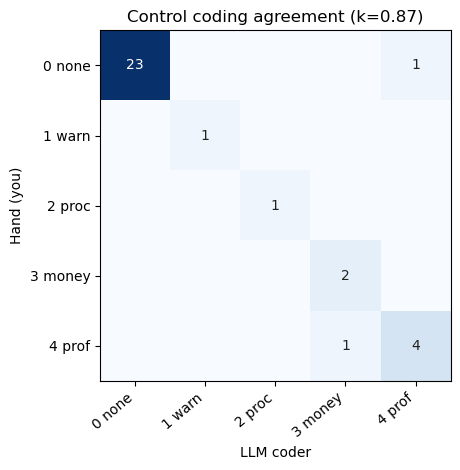

wrote ../output/figures/fig_validation_confusion.png and ../output/tables/validation_stats.txt


In [2]:
cm = confusion_matrix(h, m, labels=[0,1,2,3,4]); names=["0 none","1 warn","2 proc","3 money","4 prof"]
fig, ax = plt.subplots(figsize=(5.4,4.8)); ax.imshow(cm, cmap="Blues")
ax.set_xticks(range(5)); ax.set_yticks(range(5)); ax.set_xticklabels(names,rotation=40,ha="right"); ax.set_yticklabels(names)
for i in range(5):
    for j in range(5):
        if cm[i,j]: ax.text(j,i,cm[i,j],ha="center",va="center",color="white" if cm[i,j]>cm.max()*0.6 else "#222")
ax.set_ylabel("Hand (you)"); ax.set_xlabel("LLM coder"); ax.set_title(f"Control coding agreement (k={k:.2f})")
plt.tight_layout(); os.makedirs("../output/figures",exist_ok=True); os.makedirs("../output/tables",exist_ok=True)
plt.savefig("../output/figures/fig_validation_confusion.png", dpi=200); plt.show()
open("../output/tables/validation_stats.txt","w").write("\n".join(lines)+"\n")
print("wrote ../output/figures/fig_validation_confusion.png and ../output/tables/validation_stats.txt")

In [3]:
ok = d["hand_severity"].notna() & d["llm_severity"].notna()
dd = d[ok].copy()
dd["hand_severity"] = dd["hand_severity"].astype(int)
dd["llm_severity"]  = dd["llm_severity"].astype(int)
dis = dd[dd["hand_severity"] != dd["llm_severity"]][["case_name","hand_severity","llm_severity"]]
print(f"{len(dis)} disagreements:")
print(dis.to_string(index=False))

2 disagreements:
                  case_name  hand_severity  llm_severity
             H.R. v. P.J.E.              4             3
Margarita O. v. Fernando I.              0             4
